# **6.8701 | 6.8700[J] | 20.S900 | 20.S948 | HST.507[J]**



#**Fall 2025 Problem Set 1 (70/75 pts)**

Due: Monday September 29 at 11:59 PM EDT on Gradescope.

Create a copy of this notebook and work on your local copy.

Upload a PDF of your notebook to Gradescope.

## Edits since initial version released

1. 9/16/25 @ 6:30 pm: Removed unnecessary code from 3.2
2. 9/27/25 @ 7:00 pm: Fixed docstring for ```get_new_position``` in 2.2

## Acknowledge any collaborators here (including gen AI tools, listing chat links)

Please list collaborators here:



Please list AI chat links here (indicate which chats were used for which problems):

## Imports/Installation

In [ ]:
%pip install scikit-learn scipy pyranges biopython pyjaspar pysam pyfaidx logomaker anndata torch

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
from pyjaspar import jaspardb
import anndata
import pyranges as pr
import pysam
import torch
import logomaker
from pyfaidx import Fasta
from scipy.stats import pearsonr
from torch import nn
from torch.utils.data import Dataset, DataLoader
import random
from math import sqrt

# **Question 1: K-means clustering on gene expression data (10 pts)**

In this problem, you will implement K-means clustering on the expression profiles of two genes across a set of breast cancer patients. We have collected expression data from a pair of tissue types from the same set of 700 patients. We now wish to find clusters in this data that correspond to different breast cancer subtypes.

## 1.1 Implementing K-means (5 pts)

Your first task is to add code to the following code block to implement the K-means algorithm. To do this, you will have to complete the `assignPoints` and `recalculateCtrs` functions, and then add calls to these functions to the
`run_kmeans` function.

In [12]:
def distance(pt1, pt2):
    """
    Calculate the Euclidean distance between two 2D points.

    Args:
        pt1 (list): First point as [x, y] coordinates
        pt2 (list): Second point as [x, y] coordinates

    Returns:
        float: Euclidean distance between the two points

    Example:
        >>> distance([0, 0], [3, 4])
        5.0
    """
    return sqrt((pt1[0]-pt2[0])**2 + (pt1[1]-pt2[1])**2)

def determine_closest(pt, ctrs):
    """
    Find the index of the centroid closest to a given point.

    Args:
        pt (list): A 2D point as [x, y] coordinates
        ctrs (list): List of centroid coordinates, where each centroid is [x, y]

    Returns:
        int: Index (0, 1, 2, ...) of the closest centroid in the ctrs list

    Example:
        >>> determine_closest([1, 1], [[0, 0], [5, 5], [10, 10]])
        0
    """

    ### YOUR CODE HERE ###

    dist = []
    for j in range(len(ctrs)):
        dist.append(distance(pt, ctrs[j]))
    return dist.index(min(dist))


    
def assignPoints(tbl, ctrs):
    """
    Assign each data point to the cluster with the nearest centroid.

    This function implements the "assignment step" of the K-means algorithm,
    where each point is assigned to the cluster whose centroid it is closest to.

    Args:
        tbl (list): List of data points, where each point is [x, y] coordinates
        ctrs (list): List of current centroid positions, where each centroid is [x, y]

    Returns:
        list: List of cluster assignments, where ptsAsgn[i] is the cluster index
              (0, 1, 2, ...) for the point tbl[i]

    Example:
        >>> assignPoints([[1, 1], [9, 9]], [[0, 0], [10, 10]])
        [0, 1]
    """

    ### YOUR CODE HERE ###

    # list of data points
    assigned = []
    for i in range(len(tbl)):
        assigned.append(determine_closest(tbl[i], ctrs))
    return assigned

def recalculateCtrs(tbl, ctrs, ptsAsgn):
    """
    Update centroid positions based on the mean of their assigned points.

    This function implements the "update step" of the K-means algorithm,
    where each centroid moves to the center of mass (average position) of
    all points assigned to its cluster.

    Args:
        tbl (list): List of data points, where each point is [x, y] coordinates
        ctrs (list): List of current centroid positions (used to determine number of clusters)
        ptsAsgn (list): List of cluster assignments from assignPoints()

    Returns:
        list: List of new centroid positions, where each centroid is [x, y]

    Example:
        >>> recalculateCtrs([[0, 0], [2, 2]], [[1, 1], [3, 3]], [0, 0])
        [[1.0, 1.0], [3, 3]]  # First cluster gets new centroid, second unchanged
    """

    ### YOUR CODE HERE ###

    new_ctrs = []
    for i in range(len(ctrs)):
        cluster_points = []
        for j in range(len(ptsAsgn)):
            if ptsAsgn[j] == i:
                cluster_points.append(tbl[j])
        mean_x = sum(p[0] for p in cluster_points)/len(cluster_points)
        mean_y = sum(p[1] for p in cluster_points)/len(cluster_points)
        new_ctrs.append([mean_x,mean_y])
    return new_ctrs        
    

def run_kmeans(dataTable):
    """
    Execute the complete K-means clustering algorithm for 3 clusters.

    Args:
        dataTable (list): List of 2D data points to cluster, where each point is [x, y]

    Returns:
        None: Function plots results at each step but doesn't return values

    Algorithm:
        1. Initialize 3 centroids at fixed positions
        2. Repeat until convergence:
           a. Assign each point to nearest centroid
           b. Plot current clustering state
           c. Update centroids to mean of assigned points
           d. Check if centroids moved less than threshold
        3. Stop when total centroid movement < 5 units
    """
    # Initializes centroids, stop criterion and step counting for clustering
    newCtrs = [[5, 0], [5, 40], [5, 80]]
    stopThreshold = 5

    ptMemb = assignPoints(dataTable, newCtrs)
    stopCrit = False
    stepCount = 0

    # Performs K-means clustering, plotting the clusters at each step
    while not stopCrit:
        stepCount += 1

        plotClusters(dataTable, ptMemb, newCtrs, stepCount)

        ### YOUR CODE HERE ###

        # Saving the old centroids by deep copying
        oldCtrs = [c.copy() for c in newCtrs]

        # Recalculate centroids
        newCtrs = recalculateCtrs(dataTable, oldCtrs, ptMemb)

        # Reassign points with the new centroids:

        ptMemb = assignPoints(dataTable, newCtrs)
        

        # Stop criterion - when centroids' total movement after a step is below the threshold
        stopDist = 0

        for i in range(len(newCtrs)):
            stopDist += np.linalg.norm(np.array(oldCtrs[i]) - np.array(newCtrs[i]))

        if stopDist < stopThreshold:
            stopCrit = True

###########################
# NO NEED TO MODIFY BELOW #
###########################


def plotClusters(tbl, ptMemb, cntrs, stepCnt):
    """
    Generate a scatterplot of the current k-means cluster assignments
    """
    pt_colors = ["salmon", "lightgreen", "lightblue"]
    ctr_colors = ["red", "green", "blue"]

    for i in range(len(cntrs)):
        pts = [tbl[j] for j in range(len(tbl)) if ptMemb[j] == i]
        plt.scatter([pt[0] for pt in pts], [pt[1] for pt in pts], color = pt_colors[i], s = 10)
        plt.scatter([cntrs[i][0]], [cntrs[i][1]], color = ctr_colors[i], s = 100, facecolors = "none")

    plt.title("Step " + str(stepCnt))
    plt.xlabel("BRCA1 Gene Expression")
    plt.ylabel("SOX2 Gene Expression")
    plt.show()

You will need to download the following [files](https://www.dropbox.com/sh/670bklch7qly756/AAAVFn3ufuUPaPcVTalsLrMZa?dl=0) and upload them to colab using the following code block.

In [8]:
!wget -c "https://www.dropbox.com/scl/fo/a8s2wtjaxhr2ijwjor2kn/APTeNgcUWpl6JT4_EPL8Ymo?rlkey=wf1m5dj0p3yrepjmr3sh5sd9k&st=8ah1czi3&dl=0" -O tissue_data.zip
!unzip -o tissue_data.zip -d tissue_data

os.unlink("tissue_data.zip")
tissue_data = {}
for fname in os.listdir("tissue_data"):
    tissue_data[fname] = pd.read_csv(os.path.join("tissue_data", fname), sep="\t", header=None).values.tolist()

--2026-01-22 16:22:54--  https://www.dropbox.com/scl/fo/a8s2wtjaxhr2ijwjor2kn/APTeNgcUWpl6JT4_EPL8Ymo?rlkey=wf1m5dj0p3yrepjmr3sh5sd9k&st=8ah1czi3&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.66.18
Connecting to www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucdb63b840818e1110c37131f96e.dl.dropboxusercontent.com/zip_download_get/Cc2Vi82kcPbm3xhKAEF5PBeyAsT_fMjYS1zmp_kq7GxOlkSTUodGBBYVQ3j3EGSYoQLlAWnvetUjdhyCCN7wOmnx9BF8sgzoE8UFFQ9cEdLjrg# [following]
--2026-01-22 16:22:55--  https://ucdb63b840818e1110c37131f96e.dl.dropboxusercontent.com/zip_download_get/Cc2Vi82kcPbm3xhKAEF5PBeyAsT_fMjYS1zmp_kq7GxOlkSTUodGBBYVQ3j3EGSYoQLlAWnvetUjdhyCCN7wOmnx9BF8sgzoE8UFFQ9cEdLjrg
Resolving ucdb63b840818e1110c37131f96e.dl.dropboxusercontent.com (ucdb63b840818e1110c37131f96e.dl.dropboxusercontent.com)... 162.125.66.15
Connecting to ucdb63b840818e1110c37131f96e.dl.dropboxusercontent.com (ucdb63b840818e1110

## 1.2 Evaluation on `tissue1` (1 pt)

Run the following code block to test your implementation on `tissue1`. If your implementation is correct, the algorithm will converge in four steps.

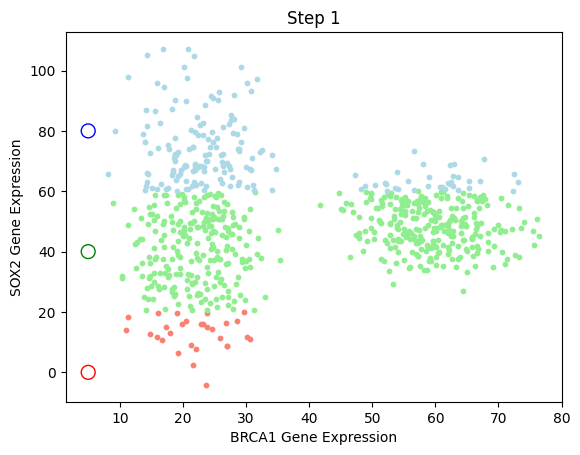

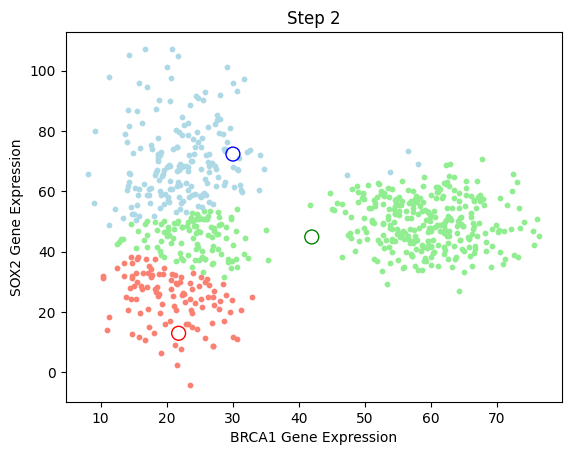

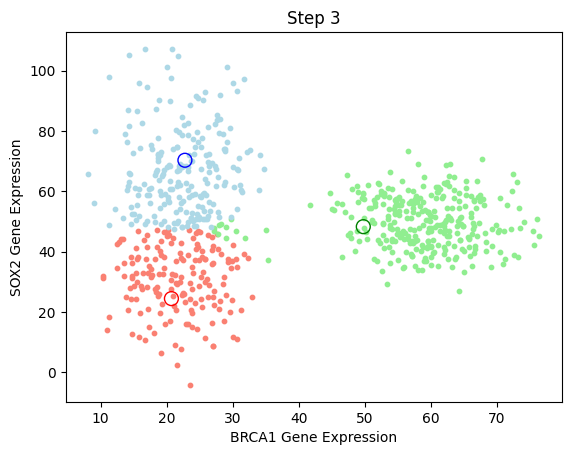

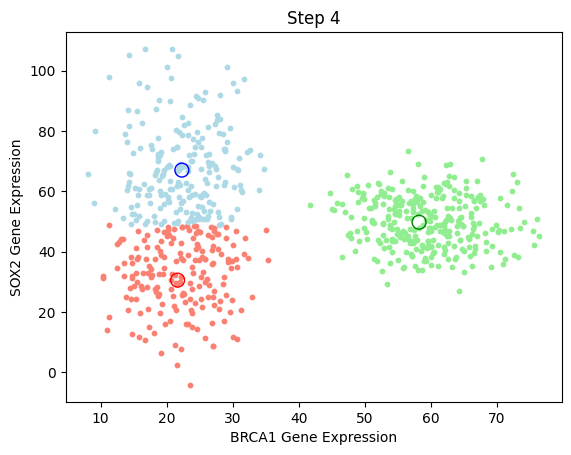

In [13]:
run_kmeans(tissue_data["tissue1_data.txt"])

## 1.3 Evaluation on `tissue2` (2 pts)
Now run your code on `tissue2` (your algorithm should converge in six steps this time). What went wrong? What strategy would you employ to find the settings of the algorithm so that it identifies the most obvious clusters, assuming you couldn't see the clusters ahead of time?

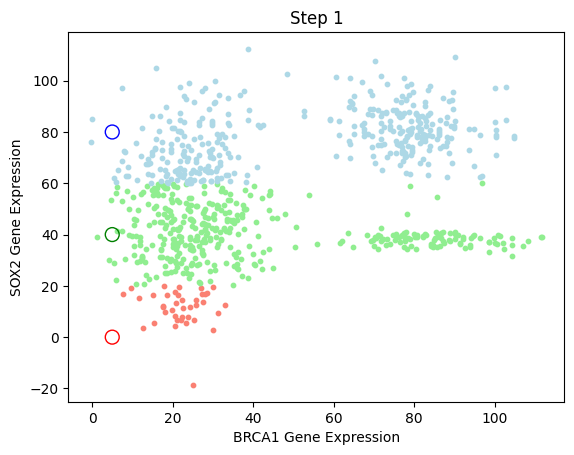

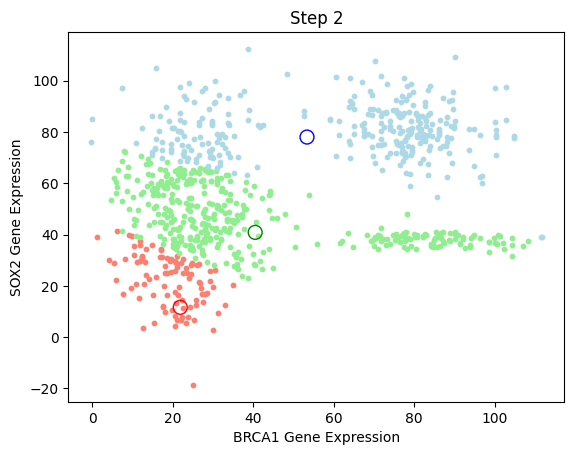

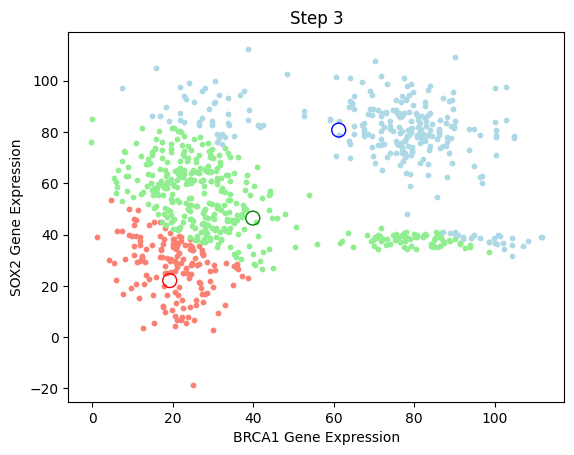

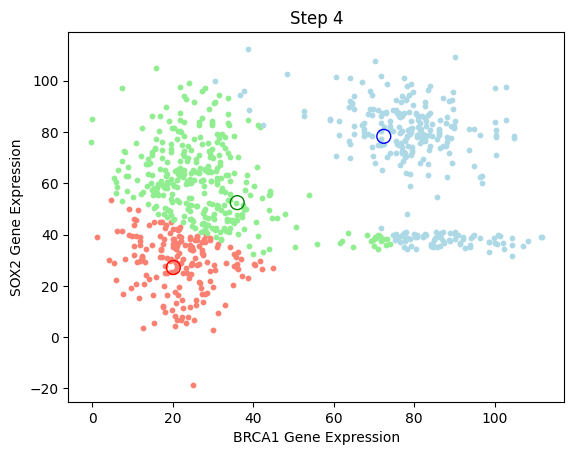

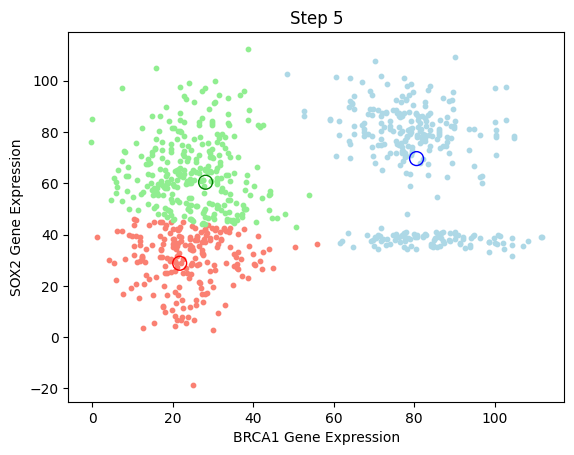

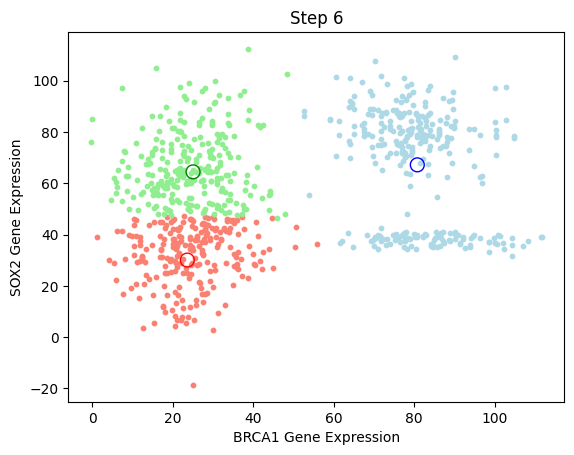

In [14]:
run_kmeans(tissue_data["tissue2_data.txt"])

## 1.4 Fuzzy K-means (2 pts)
Describe how you would implement fuzzy K-means clustering using the above set of functions. Don't worry about implementing the fuzzy K-means or generating any more plots.

# **Question 2: Gibbs sampling for motif discovery (20/25 pts)**

In this problem, you will implement a Gibbs sampler to discover sequence motifs.

Recall the Gibbs sampling algorithm for this problem: Initialize the motif position in each sequence. Until convergence: re-estimate the position weight matrix (PWM) from all the motifs except one, score every position in the excluded sequence, and sample a $k$-mer from the excluded sequence with probability proportional to the score.

## 2.1 Gibbs sampling analysis (6 pts)

Given the Gibbs sampling algorithm description above, analyze and explain:

1. Why is this a "hidden variable" problem, and how does Gibbs sampling address it?

2. What role do pseudocounts play in PWM estimation, and why are they necessary?

3. How might the choice of initial positions and convergence criteria affect the quality of discovered motifs?

## 2.2 Implementing Gibbs sampling (8 pts)

We have intentionally not specified many of the implementation details. Fill in the code below, and describe and justify the design decisions you made in your implementation. For example, how do you choose the sequence to exclude when recomputing the position weight matrix?

In [ ]:
alphabet = ["A", "C", "G", "T"]
alphabet_dict = {'A' : 0, 'C' : 1, 'G' : 2, 'T' :3 }
B = [0.25, 0.25, 0.25, 0.25]

def get_PWM(S, starts, L):
    """
    Build a Position Weight Matrix from sequences and their motif starting positions.

    This function extracts motif subsequences from each sequence, counts nucleotide
    frequencies at each position, and converts to probabilities with pseudocounts.

    Args:
        S (list): List of DNA sequences as strings
        starts (list): Starting position of motif in each sequence (same length as S)
        L (int): Length of motif

    Returns:
        list: 4 x L matrix where PWM[nucleotide_index][position] = probability
              Nucleotide indices: A=0, C=1, G=2, T=3

    Algorithm:
        1. Initialize count matrix: PWM_counts[nucleotide][position] = 0
        2. For each sequence, extract motif starting at given position
        3. Count each nucleotide at each position in the motif
        4. Convert counts to probabilities with +1 pseudocounts:
           PWM[nucleotide][position] = (count + 1) / (num_sequences + 4)

    Example:
        >>> sequences = ["ATCGAA", "GCTTAA"]
        >>> positions = [2, 0]  # Motifs: "CGAA", "GCTT"
        >>> get_PWM(sequences, positions, 4)
        # Returns PWM for aligned motifs "CGAA" and "GCTT"

    Hint: Use alphabet_dict to convert nucleotides to indices (A->0, C->1, G->2, T->3)
    """

    ### YOUR CODE HERE ###
    pass

def get_new_position(PWM, s, L):
    """
    Sample a new motif starting position in a sequence using likelihood ratios.

    This function scans all possible L-length subsequences of the sequence,
    scores each subsequence based on how well it matches the motif PWM relative
    to background, converts scores into probabilities, and samples one position
    proportional to those probabilities.

    Args:
        PWM (list): 4 x L Position Weight Matrix built from other sequences
        s (str): DNA sequence to scan for motif
        L (int): Length of motif

    Returns:
        int: Starting position of the newly sampled L-length subsequence

    Algorithm:
        1. For each possible starting position i (0 through len(s) - L):
           - Extract the k-mer s[i:i+L]
           - Compute likelihood ratio score relative to background
        2. Normalize all scores into a probability distribution
        3. Randomly sample one position according to these probabilities
        4. Return the sampled position

    Scoring:
        For each nucleotide in the k-mer:
            score *= PWM[nucleotide][position] / B[nucleotide]
        where B[nucleotide] = 0.25 (uniform background probability)

    Example:
        >>> PWM = [[0.5, 0.1], [0.1, 0.1], [0.3, 0.1], [0.1, 0.7]]  # Favors "AT"
        >>> get_new_position(PWM, "CGATCC", 2)
        2  # Likely to return position of "AT", but result may vary due to sampling
    """

    ### YOUR CODE HERE ###
    pass

def GibbsSampler(S, L):
    """
    Implement the Gibbs sampling algorithm for motif finding.

    The Gibbs sampler iteratively refines motif positions by:
    1. Randomly initializing motif starting positions in each sequence
    2. For a fixed number of iterations, randomly selecting one sequence at a time
    3. Removing the selected sequence from consideration and calculating PWM from remaining sequences
    4. Using the PWM to sample a new starting position for the selected sequence
    5. Repeating for a maximum of 50 iterations

    Args:
        S (list): List of DNA sequences as strings
        L (int): Length of motif to find

    Returns:
        list: Final Position Weight Matrix (4 x L) representing the discovered motif
    """

    ### YOUR CODE HERE ###

    # Hint: You'll need to:
    # 1. Initialize random starting positions for motif in each sequence
    # 2. For 50 iterations:
    #     a. Randomly select one sequence i to update
    #     b. Create list of sequences excluding sequence i
    #     c. Create list of starting positions excluding position i
    #     d. Calculate PWM from remaining sequences using get_PWM()
    #     e. Sample new position for sequence i using get_new_position()
    #     f. Update starting position for sequence i
    # 3. After all iterations, calculate final PWM from all sequences
    # 4. Return final PWM

    pass

###########################
# NO NEED TO MODIFY BELOW #
###########################

def get_motif_seq(PWM):
    motif_seq = ""

    for i in range(len(PWM[0])):
        comp = [row[i] for row in PWM]
        ind = max(range(len(comp)), key = comp.__getitem__)
        motif_seq += alphabet[ind]

    return motif_seq

def print_PWM(PWM, L):
    PWM_comp = []
    PWM_comp.append("||" + "|".join([str(i) for i in range(1, L + 1)]) + "|")
    PWM_comp.append("|-" * (L + 1) + "|")

    for i in range(4):
        PWM_comp.append("|" + alphabet[i] + "|" + "|".join([str(round(val, 2)) for val in PWM[i]]) + "|")

    print("\n".join(PWM_comp) + "\n")

def print_logo(PWM):
    PWM = np.array(PWM).T
    PWM = pd.DataFrame(PWM, columns = alphabet)
    logomaker.Logo(PWM, fade_below = 0.8)

def run_GibbsSampler(S, L, n):
    motif_seqs, motif_PWM = {}, {}

    for i in range(n):
        PWM = GibbsSampler(S, L)
        motif_seq = get_motif_seq(PWM)
        motif_seqs.setdefault(motif_seq, 0)
        motif_seqs[motif_seq] += 1
        motif_PWM[motif_seq] = PWM

    best_motif = max(motif_seqs.keys(), key = lambda x: motif_seqs[x])
    print("Most consistent motif: \n" + best_motif + "\n")
    print("PWM (paste into text block):")
    print_PWM(motif_PWM[best_motif], L)
    print("Sequence logo:")
    print_logo(motif_PWM[best_motif])

## 2.3 Synthetic test cases (2 pts)
We have provided four test cases. `data1` is a synthetic data set where
the motif is identical across the sequences. `data2` is a synthetic data set
with a degenerate motif. `data3` and `data4` are yeast transcription factor
binding sites of ACE2 and MBP1, respectively.

Run your Gibbs sampler on the test data to discover motifs of length 10. You will need to repeat this procedure several times on each data set due to the stochastic nature of Gibbs sampling.

Report the most consistently found PWM for each sequence.

In [ ]:
# Load synthetic data
!wget -c "https://www.dropbox.com/scl/fo/jusdkz3vp19piw33zypnv/AAfFYCmBI96sQBMfmbRLOCg?rlkey=dr0oty4gk1tgr2u3wwme7jkjx&st=zqp0eglz&dl=0" -O gibbs_motifs.zip
!unzip -o gibbs_motifs.zip -d gibbs_motifs
os.unlink("gibbs_motifs.zip")
gibbs_motifs = {}
for fname in os.listdir("gibbs_motifs"):
    with open(os.path.join("gibbs_motifs", fname), "r") as R:
        gibbs_motifs[fname] = R.read().strip().split()

In [ ]:
run_GibbsSampler(gibbs_motifs["data1.txt"], 10, 100)

In [ ]:
run_GibbsSampler(gibbs_motifs["data2.txt"], 10, 100)

In [ ]:
run_GibbsSampler(gibbs_motifs["data3.txt"], 10, 100)

In [ ]:
run_GibbsSampler(gibbs_motifs["data4.txt"], 10, 100)

**Answer here:**

`data1` PWM:

||1|2|3|4|5|6|7|8|9|10|
|-|-|-|-|-|-|-|-|-|-|-|
|A|||||||||||
|G|||||||||||
|C|||||||||||
|T|||||||||||

`data2` PWM:

||1|2|3|4|5|6|7|8|9|10|
|-|-|-|-|-|-|-|-|-|-|-|
|A|||||||||||
|G|||||||||||
|C|||||||||||
|T|||||||||||

`data3` PWM:

||1|2|3|4|5|6|7|8|9|10|
|-|-|-|-|-|-|-|-|-|-|-|
|A|||||||||||
|G|||||||||||
|C|||||||||||
|T|||||||||||

`data4` PWM:

||1|2|3|4|5|6|7|8|9|10|
|-|-|-|-|-|-|-|-|-|-|-|
|A|||||||||||
|G|||||||||||
|C|||||||||||
|T|||||||||||

## 2.4 CTCF motif discovery (4 pts)

Apply your Gibbs sampler to discover CTCF binding motifs from real ChIP-seq data from the ENCODE project.

CTCF (CCCTC-binding factor) is a highly conserved transcription factor that acts as an insulator and plays crucial roles in chromatin organization. It typically binds to a ~20bp motif with a well-characterized consensus sequence.

Your task:
1. Load CTCF ChIP-seq peaks from ENCODE experiment ENCFF029THO on chromosome 21
2. Extract DNA sequences from these binding regions
3. Use your Gibbs sampler to discover the CTCF motif (use L=14 for computational efficiency)
4. Compare your discovered motif to the known CTCF consensus CCGCGNGGNGGCAG.

In [ ]:
!wget -q -c https://hgdownload.cse.ucsc.edu/goldenpath/hg38/chromosomes/chr21.fa.gz -O chr21.fa.gz
!gunzip -f chr21.fa.gz
!samtools faidx chr21.fa

!wget -q -c https://www.encodeproject.org/files/ENCFF029THO/@@download/ENCFF029THO.bed.gz -O ENCFF029THO.bed.gz

In [ ]:
def load_narrow_peak(bed, chr:str=None):
    """
    ENCODE narrowPeak format loader
    """
    df = pd.read_csv(bed, header=None, sep="\t")
    df.columns = ["Chromosome", "Start", "End", "name", "score", "Strand", "signalValue", "pValue", "qValue", "peak"]

    if chr is not None:
      df = df.loc[df["Chromosome"] == chr, :]

    return pr.PyRanges(df)

In [ ]:
def load_encode_sequences(narrowpeak_file, fasta_file, chr_name="chr21"):
    """
    Load DNA sequences from ENCODE narrowPeak regions.

    Args:
        narrowpeak_file (str): Path to .bed.gz file with ChIP-seq peaks
        fasta_file (str): Path to chromosome FASTA file
        chr_name (str): Chromosome name to filter for

    Returns:
        list: DNA sequences from peak regions as strings
    """

    ### YOUR CODE HERE ###

    # Hint:
    # 1. Use your load_narrow_peak() function to load the narrowPeak regions for the chromosome.
    # 2. Use pyfaidx.Fasta(fasta_file) to load the FASTA sequence.
    # 3. Iterate over the peaks DataFrame (peaks.df) and extract sequences from fasta[chr_name][start:end].
    # 4. Append each extracted sequence to a list and return it.

    pass

# Load CTCF sequences and run motif discovery
ctcf_sequences = load_encode_sequences("ENCFF029THO.bed.gz", "chr21.fa", "chr21")
print(f"Loaded {len(ctcf_sequences)} CTCF binding sequences from chr21")
print(f"Average sequence length: {np.mean([len(seq) for seq in ctcf_sequences]):.1f} bp")

# Discover CTCF motif (L=14 for computational efficiency)
print("\nDiscovering CTCF motif...")
run_GibbsSampler(ctcf_sequences, 14, 50)

Comparison of discovered motif to CCGCGNGGNGGCAG:

## 2.5 **(Optional for undergraduate students)** Convolutional neural network for motif finding (5 pts)

Implement a simple PyTorch CNN to classify CTCF sequences for the same data.

In [ ]:
# Load CTCF sequences using the function students already implemented
ctcf_sequences = load_encode_sequences("ENCFF029THO.bed.gz", "chr21.fa", "chr21")

# Prepare positive examples (CTCF binding sites)
S = []
for seq in ctcf_sequences:
    if len(seq) <= 500:
        S.append((seq.upper(), 1))

# Using the pyfaidx library to extract sequences from the file "chr21.fa".
# Randomly sample 3000 sequences with lengths between 350 and 500
# from the fasta sequence. These sequences are uppercased and
# tagged with a label '0'.
seq = Fasta("chr21.fa")[0]
for _ in range(3000):
    i = np.random.randint(len(seq))
    l = np.random.randint(350, 500)
    t = str(seq[i:i+l])
    S.append((t.upper(), 0))  # Random sequences labeled as 0

# Split into train and test set
np.random.shuffle(S)
split = int(0.8 * len(S))  # 80/20 split
train = S[:split]
test = S[split:]
print(f"Train: {len(train)} \tTest: {len(test)}")

# One-hot encoding function
def one_hot(seq):
    while len(seq) < 500:
        seq += 'N'
    nd = {
        'A': [1.0,0.0,0.0,0.0],
        'C': [0.0,1.0,0.0,0.0],
        'G': [0.0,0.0,1.0,0.0],
        'T': [0.0,0.0,0.0,1.0],
        'N': [0.0,0.0,0.0,0.0]
    }
    return np.array([nd[x] for x in seq]).T

class SeqDataset(Dataset):
    def __init__(self, data):
        """
        Create a PyTorch dataset from sequence data.

        Args:
            data: List of (sequence, label) tuples
        """

        ### YOUR CODE HERE ###

        # Hint:
        # 1. Separate sequences and labels
        # 2. One-hot encode sequences and convert to torch tensors
        # 3. Convert labels to torch tensors

        pass

    def __getitem__(self, idx):

        ### YOUR CODE HERE ###
        pass

    def __len__(self):

        ### YOUR CODE HERE ###
        pass

# Create data loaders
train_loader = DataLoader(SeqDataset(train), batch_size=256)
test_loader = DataLoader(SeqDataset(test), batch_size=256)

def train_model(model, train_loader, optimizer):
    """
    Train the model for one epoch.

    Returns:
        tuple: (average_loss, accuracy)
    """
    model.train()
    total_loss = 0
    total_correct = 0
    total_items = 0

    for input, label in train_loader:

        ### YOUR CODE HERE ###

        # Hint: Standard training loop
        # 1. Zero gradients
        # 2. Forward pass
        # 3. Calculate loss (use nn.BCELoss())
        # 4. Backward pass
        # 5. Update weights
        # 6. Track loss and accuracy

    return total_loss/len(train_loader), total_correct/total_items

def test_model(model, test_loader):
    """
    Evaluate model on test data.

    Returns:
        tuple: (average_loss, accuracy)
    """
    model.eval()

    ### YOUR CODE HERE ###

    # Hint: Similar to training but with torch.no_grad()
    # and no gradient updates

    pass

# Define CNN architecture
model = nn.Sequential(
    ### YOUR CODE HERE ###
    # Hint: Build a CNN with:
    # 1. Conv1d layer (input channels=4, output channels=32, kernel_size=3)
    # 2. ReLU activation
    # 3. MaxPool1d (kernel_size=2)
    # 4. Flatten layer
    # 5. Linear layer (calculate input features from conv output)
    # 6. ReLU activation
    # 7. Final linear layer (output size=1)
    # 8. Sigmoid activation
)

optimizer = torch.optim.Adam(model.parameters())

# Train and evaluate
train_loss, train_acc = train_model(model, train_loader, optimizer)
test_loss, test_acc = test_model(model, test_loader)

print(f"Train loss: {train_loss:.4f}\tTrain accuracy: {train_acc:.4f}")
print(f"Test loss: {test_loss:.4f}\tTest accuracy: {test_acc:.4f}")

# **Question 3: Hidden Markov Models (22 pts)**

In this problem, we will implement the eight-state Hidden Markov Model described in lecture to annotate regions as CpG islands, or regions with high CpG dinucleotide frequency. Recall the model has states 𝐴+, 𝐶+, 𝐺+, 𝑇+ which emit nucleotides within CpG islands and states 𝐴−, 𝐶−, 𝐺−, 𝑇− which emit nucleotides outside CpG islands.

## 3.1 Implement the eight-state Hidden Markov Model (6 pts)

Fill out the code below. The training data is the sequence of human chromosome 21 and an existing CpG island annotation which we will use as ground truth. Train the model by computing the maximum likelihood estimates of the model parameters (recall these are relative frequencies). Please also provide:

1. Description of how you handle zeroes in the estimated parameters. (Hint: you may need to do some smoothing in the emission probability matrix to avoid calculating $\log(0)$)
2. The initial state distribution and justification for how it was chosen.
3. The final transition probability matrix.
4. The final emission probability matrix.


In [2]:
!wget https://hgdownload.cse.ucsc.edu/goldenpath/hg38/chromosomes/chr21.fa.gz
!wget https://hgdownload.cse.ucsc.edu/goldenpath/hg38/chromosomes/chr22.fa.gz
!wget https://hgdownload.cse.ucsc.edu/goldenpath/hg38/database/cpgIslandExt.txt.gz
# Schema at https://hgdownload.cse.ucsc.edu/goldenpath/hg38/database/cpgIslandExt.sql

--2026-02-04 11:09:26--  https://hgdownload.cse.ucsc.edu/goldenpath/hg38/chromosomes/chr21.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12709705 (12M) [application/x-gzip]
Saving to: 'chr21.fa.gz'

chr21.fa.gz         100%[===================>]  12.12M  3.71MB/s    in 3.3s    

2026-02-04 11:09:31 (3.71 MB/s) - 'chr21.fa.gz' saved [12709705/12709705]

--2026-02-04 11:09:31--  https://hgdownload.cse.ucsc.edu/goldenpath/hg38/chromosomes/chr22.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12255678 (12M) [application/x-gzip]
Saving to: 'chr22.fa.gz'

chr22.fa.gz         100%[===================>]  11.69M  3.30

In [16]:
# Decompress input files
#%cd content
!gzip -d cpgIslandExt.txt.gz
!gzip -d chr21.fa.gz
!gzip -d chr22.fa.gz

gzip: can't stat: cpgIslandExt.txt.gz (cpgIslandExt.txt.gz.gz): No such file or directory
gzip: can't stat: chr21.fa.gz (chr21.fa.gz.gz): No such file or directory
gzip: can't stat: chr22.fa.gz (chr22.fa.gz.gz): No such file or directory


In [21]:
#%cd content

/Users/nickmahtani/Documents/Courses/Manolis/content


In [22]:
# Extract CpG regions as a list of coordinate pairs (start and end positions of known CpG islands)
cpg_file = open("cpgIslandExt.txt")
cpg_line = cpg_file.readline()

cpg_regions = []
while(cpg_line):
    cpg_split = cpg_line.split()
    if(cpg_split[1] == "chr21"):
        region_start = int(cpg_split[2])
        region_end = int(cpg_split[3])
        cpg_regions.append([region_start, region_end])
    cpg_line = cpg_file.readline()
cpg_file.close()

In [33]:
len(cpg_regions)

446

In [36]:
cpg_regions[0][1]

5023177

In [43]:
# Open the file for reading
with open("chr21.fa", 'r') as training_file:
    
    # Skip the header
    training_file.readline()
    training_file

<_io.TextIOWrapper name='chr21.fa' mode='r' encoding='UTF-8'>


In [45]:
# Define the alphabet of valid DNA bases
alphabet = ["A", "C", "G", "T"]

# Initialize matrices and distributions for transition probabilities and initial states


# My code starts #######################################################################

# Since there are 8 hidden states, the transition matrix will be 8x8: 
count_matrix = np.zeros((8,8))

# Initial state count vector:
initial_state_distribution = np.zeros(8)



# My code ends #######################################################################


# Hint: You will need two matrices:
# 1. A count_matrix to track transitions between states (what size should this be?)
# 2. An initial_state_distribution to track how often each state occurs



# My code starts #######################################################################


# Genomic position counter for the FASTA files
gpc=0

# CpG region index for the CpG file
region_idx = 0

# Transitions between states

prev_state = None
state = None


# Open the file for reading
with open("chr21.fa", 'r') as training_file:
    
    # Skip the header
    training_file.readline()
    
    for line in training_file:
        line = line.strip().upper() # make sure that this is necessary and removing /n
        
        for base in line:

            # initializing start and end locations of the cpg island
            if region_idx < len(cpg_regions):
                start = cpg_regions[region_idx][0]
                end = cpg_regions[region_idx][1]
            else:
                start = end = None

            # checking if we have left a CpG island
            if region_idx < len(cpg_regions) and gpc >= end:
                region_idx += 1 
                if region_idx < len(cpg_regions):
                    start = cpg_regions[region_idx][0]
                    end = cpg_regions[region_idx][1]
                else:
                    start = end = None

            # checking if we are inside a CpG region
            if region_idx < len(cpg_regions) and start <= gpc < end:
                in_cpg = True
            else:
                in_cpg = False

            # Skipping Ns

            if base not in alphabet:
                prev_state=None
                gpc += 1
                continue

            #converting nucleotides to state indexes
            base_idx = alphabet.index(base)

            # adding 4 if we are inside a cpg island
            state = base_idx + (4 if in_cpg else 0)

            # counting state occurance for initial distribution
            #if prev_state is None:
            initial_state_distribution[state] += 1

            # updating emissions matrix
            emission_counts[state][base_idx] += 1

            # updating transition matrix
            if prev_state is not None:
                count_matrix[prev_state][state] +=1
                
            prev_state = state
        
                
            # incrementing genomic position
            gpc += 1
            
# My code ends #######################################################################


    # Hint: You'll need to:
    # 1. Initialize tracking variables (previous nucleotide, position, CpG region index)
    # 2. For each character in each line:
    #    - Convert nucleotide to state index (0-3 for background, 4-7 for CpG regions)
    #    - Check if current position is within a CpG region
    #    - Count state occurrences for initial distribution
    #    - Count transitions between consecutive states
    #    - Update position and CpG region tracking
    # 3. Remember: states 0-3 are A-, C-, G-, T- and states 4-7 are A+, C+, G+, T+
    # Note: some characters in the genome file may not be valid DNA bases (e.g., 'N').
    #    - If you skip these characters, make sure to still increment your position counter,
    #      so the genomic coordinate stays synchronized with CpG regions.
    #    - Failing to do this can cause CpG region detection to fail or produce incorrect predictions

# Normalize the initial state distribution to turn counts into probabilities
# Calculate the transition probability matrix
# Hint: use a smoothing technique

### YOUR CODE HERE ###

# Normalizing the intial state distribution
initial_state_distribution /= initial_state_distribution.sum()

# Normalizing the transition probability matrix with smoothing

transition_matrix = (count_matrix + 1)/ (count_matrix.sum(axis = 1, keepdims=True)+8)
            
# initial_state_distribution = ?
# transition_matrix = ?

In [46]:
# Print transition matrix as a dataframe
rows = [base + '-' for base in alphabet] + [base + '+' for base in alphabet]
cols = [base + '-' for base in alphabet] + [base + '+' for base in alphabet]

df_transition = pd.DataFrame(transition_matrix, index=rows, columns=cols)
df_transition = df_transition.round(8)

df_transition

,A-,C-,G-,T-,A+,C+,G+,T+
A-,0.331885,0.171911,0.233981,0.262215,8.000000e-08,0.000008,8.000000e-08,8.000000e-08
C-,0.359994,0.247836,0.052881,0.339266,1.200000e-07,0.000022,1.200000e-07,1.200000e-07
G-,0.296300,0.205282,0.249115,0.249290,1.200000e-07,0.000013,1.200000e-07,1.200000e-07
T-,0.216856,0.201453,0.246291,0.335393,8.000000e-08,0.000006,8.000000e-08,8.000000e-08
A+,0.000020,0.000020,0.000020,0.000020,1.742580e-01,0.295291,4.110554e-01,1.193164e-01
C+,0.000008,0.000008,0.000008,0.000008,1.562065e-01,0.367759,2.942073e-01,1.817943e-01
G+,0.000516,0.000916,0.001466,0.000850,1.548418e-01,0.345258,3.589515e-01,1.372003e-01
T+,0.000018,0.000018,0.000018,0.000018,7.505024e-02,0.364235,3.628176e-01,1.978255e-01


In [48]:
# Generate emission probability matrix

alpha = 1e-7 # Smoothing parameter

# Initialize the emission matrix
emission_matrix = np.zeros((8, 4))

# Fill in the emission probability matrix based on given conditions
# Hint: Each state should have high probability (~1.0) for its corresponding nucleotide
# and very low probability (alpha) for other nucleotides
# Remember: states 4-7 correspond to the same nucleotides as states 0-3

# My code starts #######################################################################

for i in range(8):
    base = i
    if i>=4:
        base -= 4
    for j in range(4):
        if base == j:
            emission_matrix[i][j] = 1-3*alpha
        else:
            emission_matrix[i][j] = alpha
            

# My code ends #######################################################################




In [49]:
# Print emission probability matrix as a dataframe
rows = [base + '-' for base in alphabet] + [base + '+' for base in alphabet]
cols = alphabet

df_emission = pd.DataFrame(emission_matrix, index=rows, columns=cols)
df_emission = df_emission.round(10)

df_emission

,A,C,G,T
A-,9.999997e-01,1.000000e-07,1.000000e-07,1.000000e-07
C-,1.000000e-07,9.999997e-01,1.000000e-07,1.000000e-07
G-,1.000000e-07,1.000000e-07,9.999997e-01,1.000000e-07
T-,1.000000e-07,1.000000e-07,1.000000e-07,9.999997e-01
A+,9.999997e-01,1.000000e-07,1.000000e-07,1.000000e-07
C+,1.000000e-07,9.999997e-01,1.000000e-07,1.000000e-07
G+,1.000000e-07,1.000000e-07,9.999997e-01,1.000000e-07
T+,1.000000e-07,1.000000e-07,1.000000e-07,9.999997e-01


## 3.2 Annotate CpG islands using the Viterbi algorithm (6 pts)
Use the Viterbi algorithm to annotate CpG islands in the region surrounding the SRY (sex determining region Y)-box 10 gene (SOX10). We are interested in the region between positions 38,000,000 - 39,000,000 of human chromosome 22. Return a list of lists corresponding to the CpG annotations (e.g. [[1, 1000], [10000, 20000]]).

In [70]:
def load_test_file(path):
    """
    Load and preprocess the file
    """
    with open(path, 'r') as f:
        # Skip header
        f.readline()
        content = f.read().replace('\n', '').upper()  # Convert the entire sequence into a single string
    return content

def run_viterbi(sequence, alphabet, initial_state_distribution, emission_matrix, transition_matrix, start_pos, end_pos):
    """
    Run the Viterbi algorithm to find the most likely sequence of hidden states.

    Args:
        sequence (str): Full DNA sequence (entire chromosome)
        alphabet (list): List of valid nucleotides ['A', 'C', 'G', 'T']
        initial_state_distribution (numpy.array): Initial probabilities for each state
        emission_matrix (numpy.array): Emission probabilities (8x4 matrix)
        transition_matrix (numpy.array): Transition probabilities (8x8 matrix)
        start_pos (int): Starting position to analyze (inclusive)
        end_pos (int): Ending position to analyze (inclusive)

    Returns:
        tuple: (vit_matrix, backpointers)
            - vit_matrix: List of lists containing log probabilities for each state at each position
            - backpointers: List of lists containing the best previous state for each current state
            Both are indexed from 0 and correspond to the filtered region (start_pos to end_pos)

    Note:
        Uses log probabilities to avoid numerical underflow.
        Returns relative positions within the analyzed region.
    """

# My code starts #######################################################################

    log_initial = np.log(initial_state_distribution)
    log_emission = np.log(emission_matrix)
    log_transition = np.log(transition_matrix)

    # Step 1: Filtering the sequence to only process target region

    filtered_seq = []
    position_map = []
    for i in range(start_pos, end_pos+1):
        base = sequence[i]
        if base in alphabet:
            filtered_seq.append(base)
            position_map.append(i) # to remember the position in the chromosome
        
    num_positions = len(filtered_seq)    
    vit = np.full((num_positions,8), -np.inf) # will fill with -inf instead of 0s because i will be working in log space
    bp = np.zeros((num_positions,8), dtype = int) # we want integers not float for the back pointers

    # Step 2: Handling the first position
    
    base = filtered_seq[0]
    base_idx = alphabet.index(base)
    
    for s in range(8):
        vit[0][s] = log_initial[s]+log_emission[s][base_idx]

    # Step 3: For the subsequent positions

    for t in range(1,num_positions):
        base_idx = alphabet.index(filtered_seq[t])
        
        for s in range(8): # Current state
            best_prob = -np.inf
            best_prev_state = -1
            
            for k in range(8): # Previous states
                candidate_prob = vit[t-1][k] + log_transition[k][s] + log_emission[s][base_idx]
                
                if candidate_prob > best_prob:
                    best_prob = candidate_prob
                    best_prev_state = k

            vit[t][s] = best_prob
            bp[t][s] = best_prev_state
    return (vit, bp)
            
# My code ends #######################################################################

    # Hint: You will need two main data structures to track:
    # 1. The best probability of reaching each state at each position
    # 2. Which previous state led to that best probability (for backtracking)
    # Structure your algorithm with these key steps:
    # - Filter the sequence to only process your target region
    # - Handle the first valid position differently (no previous states to consider)
    # - For subsequent positions: find the best path to each state by considering all possible previous states
    # - Remember to work in log space to avoid numerical underflow
    # Think about: What makes the first position special in the Viterbi algorithm?


def backtrack(vit_matrix, backpointers):
    """
    Backtrack through the Viterbi matrix to find the most likely state sequence.

    Args:
        vit_matrix (list): Matrix of log probabilities from Viterbi algorithm
        backpointers (list): Matrix of backpointers from Viterbi algorithm

    Returns:
        list: Binary sequence (list) where 1 indicates CpG island, 0 indicates background
              (states 0-3 → 0, states 4-7 → 1)
    """

# My code starts #######################################################################

    last_pos = len (vit_matrix) -1
    best_final_state = np.argmax(vit_matrix[last_pos])
    path = []
    current_state = best_final_state
    
    for t in range(len(vit_matrix)-1,-1, -1): # starting from the back

        if current_state < 4:
            path.append(0)
        else:
            path.append(1)

        if t>0:
            current_state = backpointers[t][current_state] 
    path.reverse()
    # path = [1 if base >=4 else 0 for base in path]
    
    return path

# My code ends #######################################################################
        

    # Hint: Start from the final position with the highest probability state
    # Follow the backpointers to reconstruct the most likely path
    # Convert state indices to binary (CpG island vs background)
    # Remember: you will build the path backwards, so reverse it at the end


def extract_regions(cpg_results, start_pos):
    """
    Extract CpG island regions from binary classification results.

    Args:
        cpg_results (list): Binary list where 1 indicates CpG island position
                           (indexed from 0, representing relative positions in the analyzed region)
        start_pos (int): Starting position of the analyzed region (for coordinate conversion)

    Returns:
        list: List of [start, end] coordinate pairs for each CpG island region
              Coordinates are converted from relative positions to absolute
              chromosome positions (adding start_pos offset)
    """

    ### YOUR CODE HERE ###
    
# My code starts #######################################################################

    flag = 0
    islands = []
    num_results = len(cpg_results)
    
    for t in range (num_results):
        if cpg_results[t] == 1 and flag == 0:
            flag = 1
            begin = start_pos + t
        
        if cpg_results[t] == 0 and flag == 1:
            flag = 0
            end = start_pos + t 
            islands.append([begin, end])
    
    if flag == 1:
        end = start_pos + num_results
        islands.append([begin, end])

    return islands
    
# My code ends #######################################################################

    
    # Hint: Scan through the binary sequence looking for runs of 1s
    # When you find a CpG island region, record its start and end positions
    # Convert relative positions to absolute chromosome coordinates


# Load chromosome 22
test_sequence = load_test_file("chr22.fa")

# Define the region of interest (SOX10 gene region)
START_POS = 38000000
END_POS = 39000000

# Run the Viterbi algorithm
# Backtrack to get the most likely sequence of states
# Extract the CpG regions
# Output the results

# My code starts #######################################################################

(vit, bp) = run_viterbi(test_sequence, alphabet, initial_state_distribution, emission_matrix, transition_matrix, START_POS, END_POS)
path = backtrack(vit, bp)
islands = extract_regions(path, START_POS)

print(f"Regions found: {islands}")
print(f"Number of regions found: {len(islands)}")

# My code ends #######################################################################


# Expected output format:
# Regions found: [[start1, end1], [start2, end2], ...]
# Number of regions found: X

/var/folders/tl/f93f8drj74xcr8q6mkvq680m0000gn/T/ipykernel_44881/1048748610.py:37: RuntimeWarning: divide by zero encountered in log
  log_initial = np.log(initial_state_distribution)


Regions found: [[38000102, 38000265], [38003243, 38003389], [38007212, 38007711], [38008591, 38008700], [38009080, 38009442], [38016313, 38016589], [38016669, 38016782], [38016915, 38017797], [38018796, 38019710], [38026461, 38026628], [38026733, 38027798], [38030768, 38031108], [38031507, 38031830], [38032689, 38032923], [38033341, 38034987], [38035388, 38035849], [38038241, 38039226], [38039327, 38039889], [38041064, 38041485], [38042084, 38043367], [38045990, 38046832], [38049954, 38051129], [38051379, 38051601], [38052280, 38053208], [38056397, 38056649], [38057054, 38057694], [38064615, 38064756], [38065513, 38066053], [38066275, 38066678], [38066912, 38067297], [38067593, 38069632], [38069992, 38070972], [38071478, 38073327], [38073599, 38074038], [38074234, 38075769], [38075977, 38076634], [38076764, 38077035], [38077137, 38078660], [38079850, 38080043], [38080636, 38083303], [38083687, 38085323], [38085633, 38086771], [38087055, 38087271], [38087543, 38090028], [38090132, 38090

## 3.3 Evaluation (4 pts)

Evaluate the performance of the model by computing its false positive and false negative rates on the test data against the ground truth annotation. Define a true positive to be a predicted CpG island of which at least 50% overlaps a true CpG island.

Are these two rates equal? If not, what causes this bias?


In [66]:
def get_overlap(region1, region2):
    """
    Calculate overlap between two regions.

    Args:
        region1 (list): [start, end] coordinates of first region
        region2 (list): [start, end] coordinates of second region

    Returns:
        int: Length of overlap between the regions

    Hint: Find the intersection of the two regions and return its length.
    Handle cases where regions don't overlap (return 0).
    """

    ### YOUR CODE HERE ###

    # finding the later start
    if region1[0] <= region2[0]:
        start = region2[0]
    else:
        start = region1[0]

    # finding the earlier end
    if region1[1] <= region2[1]:
        end = region1[1]
    else:
        end = region2[1]

    overlap = end - start

    # if there isnt an overlap
    if overlap < 0:
        return 0

    return overlap


def check_overlap(coord, region):
    """
    Check whether a given coordinate falls within a region.

    Args:
        coord (int): Position to check
        region (list): [start, end] coordinates of region

    Returns:
        bool: True if coordinate is within region, False otherwise

    Hint: Check if coord is between region[0] and region[1] (inclusive)
    """

    ### YOUR CODE HERE ###

    return region[0] <= coord <= region[1]


def load_ground_truth_regions(start_pos, end_pos):
    """
    Load annotated CpG regions that overlap with the target region.

    Args:
        start_pos (int): Start of target region
        end_pos (int): End of target region

    Returns:
        list: List of [start, end] coordinate pairs for CpG islands in target region

    Hint:
    1. Open "/content/cpgIslandExt.txt"
    2. Read line by line using readline() loop
    3. Split each line and check if column 1 == "chr22"
    4. Extract start (column 2) and end (column 3) positions
    5. Keep regions that overlap with target region using the condition:
       (region_end >= start_pos and region_end <= end_pos) or (region_start >= start_pos and region_start <= end_pos)
    """

    ### YOUR CODE HERE ###


    cpg_regions = []
    
    with open("cpgIslandExt.txt") as cpg_file:
        for line in cpg_file:
            parts = line.split()

            if parts[1] == "chr22":
                region_start = int(parts[2])
                region_end = int(parts[3])
                
                if get_overlap([region_start,region_end], [start_pos, end_pos])>0:
                    cpg_regions.append([region_start, region_end])
                    
    return cpg_regions


def evaluate_islands(predicted_regions, true_regions):
    """
    Evaluate predicted CpG islands against ground truth using region-level analysis.

    Args:
        predicted_regions (list): List of [start, end] pairs from your model
        true_regions (list): List of [start, end] pairs from annotations

    Returns:
        numpy.array: 2x2 confusion matrix for island-level predictions

    Hint:
    1. Create 2x2 confusion matrix: [[TP, FN], [FP, TN]]
    2. For each predicted region, check if it overlaps significantly with any true region
    3. For regions between predicted islands, check if they contain true CpG islands
    4. Use get_overlap() and check if overlap >= 50% of the true region length
    """

    ### YOUR CODE HERE ###

    # initializing the confusion matrix
    confusion_matrix = np.zeros((2,2), dtype=int) # [[TP, FN],[FP,TN]]

    
    for i in range(len(predicted_regions)):
        pred_region = predicted_regions[i]

        if i == len(predicted_regions)-1:
            gap = None
        else:
            gap = [pred_region[1] + 1, predicted_regions[i+1][0]-1] # i dont think i did the -1 everywhere

        cpg_found = False
        non_cpg_found = False
        
        for true_region in (true_regions):
            cutoff = (true_region[1]-true_region[0])*0.5

            overlap = get_overlap(pred_region,true_region)
            if overlap >= cutoff:
                cpg_found = True

            if gap is not None:
                
                non_overlap = get_overlap(gap,true_region)
                if non_overlap >= cutoff:
                    non_cpg_found = True

        # Updating the confusion matrix
        if cpg_found:
                confusion_matrix[0][0] += 1 # True positive
        else:
                confusion_matrix[1][0] += 1 # False positive

        if non_cpg_found:
                confusion_matrix[0][1] += 1  # False negative
        else:
                confusion_matrix[1][1] += 1  # True negative
    
    return confusion_matrix

        

def evaluate_positions(cpg_results, true_regions, base_offset):
    """
    Evaluate predictions at the nucleotide position level.

    Args:
        cpg_results (list): Binary list where 1 = CpG island prediction, 0 = background
        true_regions (list): List of [start, end] pairs from annotations
        base_offset (int): Starting position offset (to convert relative to absolute coordinates)

    Returns:
        numpy.array: 2x2 confusion matrix for position-level predictions

    Hint:
    1. Create 2x2 confusion matrix: [[TP, FN], [FP, TN]]
    2. For each position in cpg_results:
       - Convert relative position to absolute: base_offset + position
       - Check if absolute position falls within any true CpG region using check_overlap()
       - Compare prediction (0 or 1) with ground truth (in CpG region or not)
       - Update appropriate cell in confusion matrix
    """

    ### YOUR CODE HERE ###

    # initializing the confusion matrix
    confusion_matrix = np.zeros((2,2), dtype=int) # [[TP, FN],[FP,TN]]

    
    for i in range(len(cpg_results)):
        is_island = False
        actual_pos = i + base_offset
        for true_region in true_regions: 
            if check_overlap(actual_pos, true_region):
                is_island = True
                break
        if cpg_results[i] == 1:
            if is_island == True:
                confusion_matrix[0][0] += 1 # True positive
            else:
                confusion_matrix[1][0] += 1 # False positive
        else:
            if is_island == False:
                confusion_matrix[1][1] += 1  # True negative
            else:
                confusion_matrix[0][1] += 1  # False negative
                
    return confusion_matrix


def calculate_rates_from_confusion_matrix(confusion_matrix):
    """
    Calculate false positive and false negative rates from confusion matrix.

    Args:
        confusion_matrix (numpy.array): 2x2 matrix [[TP, FN], [FP, TN]]

    Returns:
        tuple: (false_positive_rate, false_negative_rate)

    Hint:
    - Confusion matrix structure: [[TP, FN], [FP, TN]]
    - False Positive Rate = FP / (FP + TN) = confusion_matrix[1,0] / sum(confusion_matrix[1,:])
    - False Negative Rate = FN / (TP + FN) = confusion_matrix[0,1] / sum(confusion_matrix[0,:])
    """

    ### YOUR CODE HERE ###
    
    false_positive_rate = confusion_matrix[1,0] / sum(confusion_matrix[1,:])
    false_negative_rate = confusion_matrix[0,1] / sum(confusion_matrix[0,:])

    
    return (false_positive_rate, false_negative_rate)



# Constants
START_POS = 38000000
END_POS = 39000000
BASE_OFFSET = 38000000

# Load ground truth regions for chr22 in the target region
true_regions = load_ground_truth_regions(START_POS, END_POS)

# Get your predicted regions and position-level results

cpg_results = path  # Binary list from backtrack() function 
predicted_regions = islands # Output from extract_regions()
                  

print(f"Found {len(true_regions)} annotated CpG islands in target region")
print(f"Predicted {len(predicted_regions)} CpG islands")

# Method 1: Island-level evaluation
print("\n=== Island-Level Evaluation ===")
island_confusion_matrix = evaluate_islands(predicted_regions, true_regions)
print("Island Confusion Matrix:")
print(island_confusion_matrix)

island_fpr, island_fnr = calculate_rates_from_confusion_matrix(island_confusion_matrix)
print(f"Island-level False Positive Rate: {island_fpr:.3f}")
print(f"Island-level False Negative Rate: {island_fnr:.3f}")

# Method 2: Position-level evaluation
print("\n=== Position-Level Evaluation ===")
position_confusion_matrix = evaluate_positions(cpg_results, true_regions, BASE_OFFSET)
print("Position Confusion Matrix:")
print(position_confusion_matrix)

position_fpr, position_fnr = calculate_rates_from_confusion_matrix(position_confusion_matrix)
print(f"Position-level False Positive Rate: {position_fpr:.3f}")
print(f"Position-level False Negative Rate: {position_fnr:.3f}")

Found 32 annotated CpG islands in target region
Predicted 361 CpG islands

=== Island-Level Evaluation ===
Island Confusion Matrix:
[[ 32   0]
 [329 361]]
Island-level False Positive Rate: 0.477
Island-level False Negative Rate: 0.000

=== Position-Level Evaluation ===
Position Confusion Matrix:
[[ 24907    355]
 [193223 781516]]
Position-level False Positive Rate: 0.198
Position-level False Negative Rate: 0.014


## 3.4 Parameter tuning (2 pts)

Could we improve the performance of the model by tuning parameters? If so, describe how you would do so (you do not have to implement your suggestions). If not, describe and justify some modifications to the model which could reduce its error rate.


## 3.5 Model size (2 pts)

One change to your model that you might consider is to add more states to it. Nevertheless, the number of states will still be finite. Explain why this limits the model's ability to capture phenomena that span arbitrarily large sequences.


## 3.6 Multiple lines of evidence (2 pts)

One alternative approach to improve the quality of annotations is combining multiple lines of evidence.

Do not implement, but describe and justify some biological criteria for filtering the output of a sequence-based CpG island classifier to improve its performance.

# **Question 4: Enhancer-gene linking (18 pts)**

In this module, you will attempt a few methods for linking enhancers to genes, as well as estimating gene expression from chromatin data.


Using EpiMap (http://compbio.mit.edu/epimap/) data, we can look at enhancer regions and see which genes they control.

## 4.1 Find all enhancer-gene pairs within 100kb from the TSS of a gene (6 pts)


Each row of the AnnData objects corresponds to a sample, and each column of the anndata object corresponds to a feature, i.e. a peak or a gene.

Approach: Find enhancer-gene pairs by:
1. Identifying regions that are both ChromHMM-predicted enhancers AND show chromatin activity
2. Linking these active enhancers to genes within 100kb of the gene's transcription start site
3. Requiring evidence from both H3K27ac and DNase-seq for higher confidence predictions

Use the genomic coordinate information (`.var`) to find spatial overlaps between enhancers and gene regulatory regions. Specifically, find peaks that overlap ChromHMM enhancer states using the activity data from brain sample BSS00369. Fill in the code below.



In [ ]:
!wget -c "https://www.dropbox.com/scl/fo/30n3vstwklmcjw9vfciea/AEr_qKWsKUk2tl0NVtBpQUE?rlkey=h17fdw5swsnqohmf9eiffxx4z&st=69vtxosc&dl=0" -O linking.zip
!unzip -o linking.zip -d linking
os.unlink("linking.zip")

rna = anndata.read_h5ad("linking/rna.h5ad")
h3k27ac = anndata.read_h5ad("linking/H3K27ac_reduced.h5ad")
dnase = anndata.read_h5ad("linking/DNase-seq_reduced.h5ad")

In [ ]:
eqtl = pd.read_csv("linking/gtex_frontal_cortex_eQTL_hg19.bed.gz", sep="\t")

### Use the 18-state ChromHMM model
chmm = pd.read_csv("https://personal.broadinstitute.org/cboix/epimap/ChromHMM/observed_aux_18_hg19/CALLS/BSS00369_18_CALLS_segments.bed.gz", sep="\t", header=None).iloc[:, range(4)]
chmm.columns = ["Chromosome", "Start", "End", "state"]
chmm = chmm.loc[chmm["state"].str.startswith("Enh"), :]
print("Enhancer states found:", chmm["state"].value_counts())

In [ ]:
# Process H3K27ac data

### YOUR CODE HERE ###

# Hint: You need to:
# 1. Rename coordinate columns in h3k27ac.var (seqnames→Chromosome, start→Start, end→End)
# 2. Extract activity values for sample BSS00369 and add to h3k27ac.var as 'Activity_h3k27ac'
# 3. Convert to PyRanges object (store as h3k27ac_pr)
# 4. Join with ChromHMM enhancer states to find active enhancers (store as chmm_h3k27ac)
# 5. Select relevant columns and remove duplicates

# Process DNase-seq data (parallel to H3K27ac processing)

### YOUR CODE HERE ###

# Hint: Follow the same pattern as H3K27ac:
# 1. Rename columns in dnase.var
# 2. Extract activity values for BSS00369 and add as 'Activity_dnase'
# 3. Convert to PyRanges (store as dnase_pr)
# 4. Join with ChromHMM enhancer states (store as chmm_dnase)
# 5. Select columns and remove duplicates

# Process gene data and create +/- 100kb windows around TSS

### YOUR CODE HERE ###

# Hint:
# 1. Rename coordinate columns in rna.var
# 2. Convert to PyRanges (rna_pr) and then DataFrame (rna_df)
# 3. Create 100kb windows: Start = tss - 100000, End = tss + 100000
# 4. Convert back to PyRanges

# Find enhancer-gene pairs for H3K27ac data

### YOUR CODE HERE ###

# Hint:
# 1. Join chmm_h3k27ac with gene windows using containment
# 2. Convert to DataFrame and remove duplicates (store as h3k27ac_pairs_df)
# 3. Select relevant columns
# 4. Calculate distance between enhancer start and TSS

# Find enhancer-gene pairs for DNase data

### YOUR CODE HERE ###

# Hint: Follow the same pattern as H3K27ac pairs
# Store result as dnase_pairs_df

# Merge both datasets to find enhancers with both H3K27ac and DNase activity

enhancer_gene_pairs = ### YOUR CODE HERE ###

# Hint: Use merge() with inner join on all columns except 'Activity_h3k27ac'
# The DataFrames should match on genomic coordinates, gene symbols, and distances

# Display results
print(f"H3K27ac pairs: {len(h3k27ac_pairs_df)}")
print(f"DNase pairs: {len(dnase_pairs_df)}")
print(f"Combined pairs (both signals): {len(enhancer_gene_pairs)}")
print(f"Unique genes: {enhancer_gene_pairs['symbol'].nunique()}")

enhancer_gene_pairs.head()

## 4.2 Compute an activity-by-contact like model of enhancer-gene links and compare to nearest-gene (4 pts)

ABC takes the power law (provided, given a distance), multiplies by some activity, such as the geometric mean of the H3K27ac and DNase-seq activity, and then divides by all ABC scores for one gene.

Take all enhancer-promoter pairs you generated in the previous section, and compute the ABC distance (power law), and 3 ABC like scores, using activity of: H3K27ac, DNase-seq, and sqrt(H3K27ac*DNase-seq) in BSS00369, and compare all 4 predictions to GTEx eQTLs.

Limit eQTLs to the ranges of the enhancers you have, and try to see what the predictive accuracy of the linking is on the eQTLs.


In [ ]:
# Distance-based contact frequency function
def abc_distance(distance, hic_power=0.87):
    scale = -4.80 + 11.63 * hic_power
    offset = np.clip(np.abs(distance), 5000, np.inf)
    return np.exp(scale + -1 * hic_power * np.log1p(offset))

In [ ]:
# Calculate ABC distance scores for all enhancer-gene pairs

### YOUR CODE HERE ###

# Hint: Apply the abc_distance function to the 'distance' column
# Store result in new column 'ABC_distance'
# Use abs() to handle negative distances

# Calculate ABC scores using different activity measures

### YOUR CODE HERE ###

# Hint: Create three new columns by multiplying ABC_distance with:
# 1. 'ABC_h3k27ac': ABC_distance x Activity_h3k27ac
# 2. 'ABC_dnase': ABC_distance x Activity_dnase
# 3. 'ABC_sqrt': ABC_distance x sqrt(Activity_h3k27ac x Activity_dnase)

# Ensure gene symbols are strings for grouping

### YOUR CODE HERE ###

# Hint: Convert 'symbol' column to string type using astype(str)

# Calculate normalization denominators by summing ABC scores per gene

### YOUR CODE HERE ###

# Hint: Group enhancer_gene_pairs by 'symbol' and sum the ABC columns

# Define normalization function
def norm_ABC(x):
    """
    Normalize ABC scores by dividing each enhancer's score by the total for its gene.
    This models competition between enhancers for the same target gene.
    """

    ### YOUR CODE HERE ###

    # Hint: For each ABC score type, divide by the corresponding sum from ABC_sum_df
    # Access the sum using ABC_sum_df[ABC_type][x['symbol']]
    # Update x[ABC_type] with the normalized value
    # Return the modified row

    pass

# Apply normalization to all enhancer-gene pairs

### YOUR CODE HERE ###

# Validate predictions against eQTL data

### YOUR CODE HERE ###
# Hint:
# 1. Rename eqtl columns to match PyRanges format
# 2. Convert eqtl to PyRanges object
# 3. Join eQTL data with enhancer_gene_pairs using containment
# 4. Convert result to DataFrame

print("ABC model results:")
print(f"Total enhancer-gene pairs: {len(enhancer_gene_pairs)}")
print(f"Pairs with eQTL validation: {len(eqtl_ranged_df)}")
print("\nSample normalized ABC scores:")
enhancer_gene_pairs[['symbol', 'ABC_distance', 'ABC_h3k27ac', 'ABC_dnase', 'ABC_sqrt']].head()

## 4.3 Correlate enhancers to gene expression (4 pts)

Use a simple model to use H3K27ac-RNA and DNase-seq-RNA correlation with RNA-seq in different enhancer types.

Similar to 4.2, modify the algorithm to use correlation times activity instead of just activity.
So calculate three more scores, using

1. H3K27ac * Cor(H3K27ac, RNA)^2,
2. DNase-seq * Cor(DNase-seq, RNA)^2
3. sqrt(H3K27ac * DNase-seq) * Cor(sqrt(H3K27ac*DNase-seq), RNA)^2

How do each of the pairings compare? Does correlation improve certain predictions and hurt others?

In [ ]:
def correlation(A, B, wt=None):
    """
    Fast pearson correlation for one matrix against another
    """
    if wt is None:
        wt = np.ones(A.shape[1])
    wt = np.ravel(wt) / np.sum(wt)
    Am = (A.T - np.dot(A, wt)).T
    Bm = (B.T - np.dot(B, wt)).T
    Am_sum_sq = np.dot(Am * Am, wt)
    Bm_sum_sq = np.dot(Bm * Bm, wt)
    numer = np.dot(Am * Bm, wt)
    denom = np.sqrt(Am_sum_sq * Bm_sum_sq)
    cor = np.divide(numer, denom, out=np.zeros_like(numer), where=denom != 0)
    return cor

def compute_correlation(links:pd.DataFrame, rna:anndata.AnnData, dna:anndata.AnnData,
                        batch_size=1000, enh_col="gene", gene_col="gene"):
    comm_samples = list(set(rna.obs_names.values).intersection(set(dna.obs_names.values)))
    cor = np.zeros(links.shape[0])
    for start in np.arange(0, links.shape[0], batch_size):
        end = min(start + batch_size, links.shape[0])
        enhancers = links[enh_col].values[start:end]
        genes = links[gene_col].values[start:end]
        rna_data = rna[comm_samples, genes].X.T
        dna_data = dna[comm_samples, enhancers].X.T
        cor[start:end] = correlation(rna_data, dna_data)
    return cor

# Create correlation function for geometric mean activity
def compute_correlation_sqrt(links:pd.DataFrame, rna:anndata.AnnData, dna:anndata.AnnData, h3k27ac:anndata.AnnData,
                            batch_size=1000, enh_col="gene", gene_col="gene"):
    """
    Compute correlations between gene expression and geometric mean of H3K27ac and DNase activities.

    This function correlates gene expression with sqrt(H3K27ac x DNase) across samples.
    """
    ### YOUR CODE HERE ###

    # Hint: Follow the pattern from compute_correlation but:
    # 1. Find common samples across all three datasets (rna, dna, h3k27ac)
    # 2. For each batch, extract data from all three datasets
    # 3. Compute sqrt_data = sqrt(h3k27ac_data * dna_data)
    # 4. Correlate rna_data with sqrt_data

    pass


In [ ]:
# Compute correlations for all three activity measures

### YOUR CODE HERE ###

# Hint: Use the provided functions to compute three correlation arrays:
# 1. cor_h3k27ac_rna: correlation between H3K27ac activity and RNA expression
# 2. cor_dnase_rna: correlation between DNase activity and RNA expression
# 3. cor_sqrt_rna: correlation between geometric mean activity and RNA expression
# Use 'name' for enhancer column and 'symbol' for gene column

# Create correlation-weighted activity scores

### YOUR CODE HERE ###

# Hint: Create three new columns by multiplying activity by correlation squared:
# 1. 'Cor_h3k27ac_RNA' = Activity_h3k27ac × (correlation²)
# 2. 'Cor_dnase_RNA' = Activity_dnase × (correlation²)
# 3. 'Cor_sqrt_RNA' = sqrt(Activity_h3k27ac × Activity_dnase) × (correlation²)

# Normalize correlation scores by gene (similar to ABC normalization)

### YOUR CODE HERE ###

# Hint:
# 1. Create cor_list with the three correlation column names
# 2. Group by 'symbol' and sum the correlation scores (store as cor_sum_df)
# 3. Create norm_cor function that divides each score by its gene's total
# 4. Apply the normalization function to all rows

def norm_cor(x):
    """
    Normalize correlation scores so each gene's enhancers sum to 1.
    Models competition between enhancers for the same target gene.
    """

    ### YOUR CODE HERE ###

    # Hint: For each correlation score type in cor_list:
    # Divide x[cor_type] by the corresponding sum from cor_sum_df

    pass

# Apply normalization

### YOUR CODE HERE ###

# Create scatter plot showing the effect of correlation weighting
# X-axis: Raw DNase activity (Activity_dnase)
# Y-axis: Correlation-weighted DNase activity (Cor_dnase_RNA)

### YOUR CODE HERE ###

print("Correlation-enhanced results:")
print(f"Sample correlation-weighted scores:")
enhancer_gene_pairs[['symbol', 'Cor_h3k27ac_RNA', 'Cor_dnase_RNA', 'Cor_sqrt_RNA']].head()

## 4.4 Estimate gene expression from chromatin data (4 pts)

If peak-gene links can accurately capture correlation, the additive effect of them should allow for gene expression estimation.

Try to estimate the RNA-seq by aggregating the BSS00369 enhancer-gene links you have, and then correlate to BSS00368 RNA-seq expression.

(The RNA-seq file only has BSS00368, so we compare predicted expression from BSS00369 enhancer activity against observed BSS00368 RNA levels.)

Remember that the ABC links are normalized per-gene, so you may have to multiply by the activity per gene.

In [ ]:
# Create enhanced dataset with gene expression values

# Add gene expression activity
rna.var = rna.var.rename(columns={'seqnames':'Chromosome', 'start':'Start', 'end':'End'})
rna.var['Activity_rna'] = list(rna['BSS00368'].X[0])

# Recreate gene windows

### YOUR CODE HERE ###

# Hint: Convert to PyRanges, modify Start/End coordinates around TSS

# Find enhancer-gene pairs with expression data

### YOUR CODE HERE ###

# Hint: Join chmm_h3k27ac and chmm_dnase with gene windows
# Include 'Activity_rna' in your selected columns
# Calculate distances as before

# Merge datasets

### YOUR CODE HERE ###

# Hint: Merge H3K27ac and DNase pairs on common columns except 'Activity_h3k27ac'
# Store result as enhancer_rna_pairs

# Normalize gene expression values by gene (to match ABC normalization)
# 1. Group by gene symbol and sum Activity_rna values
# 2. Create normalization function that divides by gene totals
# 3. Apply normalization to all rows

### YOUR CODE HERE ###

def norm_rna(x):
    """
    Normalize gene expression the same way ABC scores were normalized.
    Each gene's expression values will sum to 1 across all its enhancer pairs.
    """

    ### YOUR CODE HERE ###
    pass

### YOUR CODE HERE ###

# Test prediction accuracy
# 1. Extract ABC predictions from enhancer_gene_pairs (use 'ABC_sqrt')
# 2. Extract actual expression from enhancer_rna_pairs (use 'Activity_rna')
# 3. Compute and print the Pearson correlation between predicted and actual values

estimate = ### YOUR CODE HERE ###  # ABC model predictions
real = ### YOUR CODE HERE ###      # Actual normalized gene expression

cor_est_real = ### YOUR CODE HERE ###
print(f"Correlation between ABC predictions and gene expression: {cor_est_real[0]:.3f}")